# Load dataset

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('C:/Users/Admin/Documents/Dissertation/MA981/2.clean_data.csv')

# Split data

## Original data

In [2]:
#Split the original data into features and target
from sklearn.model_selection import train_test_split

X = df.drop('classification',axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=10, stratify=y)

## Feature selection

### Filter method : correlation-based feature selection

In [3]:
import time

start = time.time()
correlation_matrix = df.corr()
correlation = correlation_matrix['classification'].sort_values(ascending=False)
cor_index = list((correlation.index[index]) for index, attr in enumerate(correlation) if abs(attr) >= 0.5)
X_column_corr = cor_index

#end = time.time()

print(f"Duration for Filter method is {time.time()-start} sec")

Duration for Filter method is 0.00099945068359375 sec


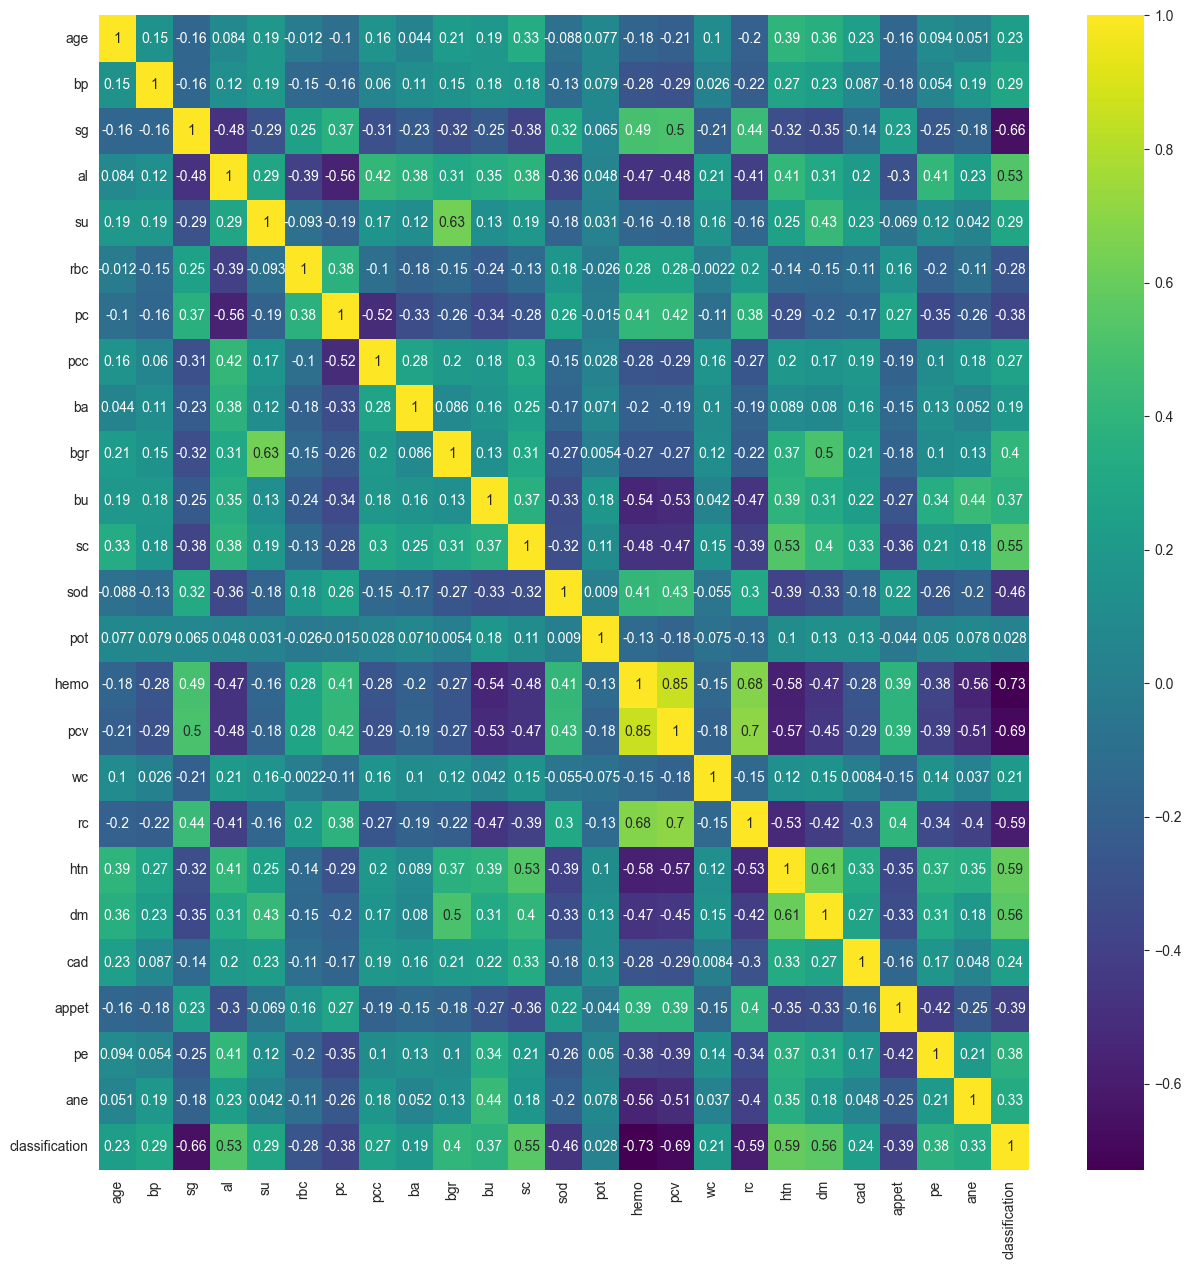

In [4]:
import seaborn as sns

plt.figure(figsize=(15,15))
sns.heatmap(correlation_matrix, annot=True, cmap = 'viridis')
plt.savefig("Correlation of classification")
plt.show()

In [5]:
filter_data = df[X_column_corr]
filter_data

,classification,htn,dm,sc,al,rc,sg,pcv,hemo
0,1,1,1,-0.395962,1.0,5.869015e-01,1.020,0.628372,1.059271
1,1,0,0,-0.801232,4.0,-1.058283e-15,1.020,-0.108649,-0.452097
2,1,0,1,0.211943,2.0,-1.058283e-15,1.010,-0.968506,-1.078762
3,1,1,0,2.238293,4.0,-9.620758e-01,1.005,-0.845669,-0.488960
4,1,0,0,-0.193327,2.0,-1.280111e-01,1.010,-0.477159,-0.341509
...,...,...,...,...,...,...,...,...,...
395,0,0,0,-1.105185,0.0,2.294455e-01,1.020,0.996882,1.169859
396,0,0,0,-0.395962,0.0,1.778423e+00,1.025,1.856739,1.464760
397,0,0,0,-1.003867,0.0,8.252061e-01,1.020,1.242555,1.206722
398,0,0,0,-0.598597,0.0,1.420967e+00,1.025,1.488229,0.616920


In [6]:
X_column_corr

['classification', 'htn', 'dm', 'sc', 'al', 'rc', 'sg', 'pcv', 'hemo']

In [7]:
print('Filter method selected features are',len(X_column_corr[1:]),':',X_column_corr[1:])

Filter method selected features are 8 : ['htn', 'dm', 'sc', 'al', 'rc', 'sg', 'pcv', 'hemo']


### Wrapper method : Stepwise method

In [8]:
#import library
from sklearn.ensemble import RandomForestClassifier
#pip install mlxtend #if you use mlxtend first time.
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [9]:
rf = RandomForestClassifier(random_state=0)

start = time.time()
# Initialize the SequentialFeatureSelector
sfs = SFS(rf,
          k_features='best',  # Select the best subset of features
          forward=True,        # Forward selection
          floating=True,       # Backward selection
          scoring='accuracy',
          cv=5)

# Fit the SFS on your data
sfs = sfs.fit(X, y)

# Get the selected feature indices

selected_features = list(sfs.k_feature_idx_)
selected_columns = df.columns[list(sfs.k_feature_idx_)+ [len(df.columns) - 1]]

end = time.time()

print("Duration for Wrapper method is",round(end-start,5),"sec")

Duration for Wrapper method is 258.73985 sec


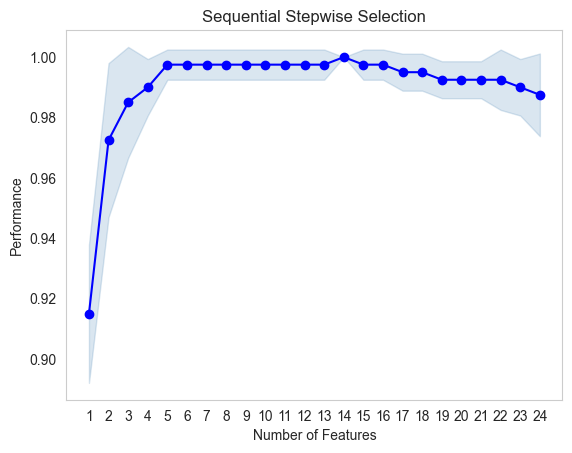

In [10]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

wrap = plot_sfs(sfs.get_metric_dict())
plt.title('Sequential Stepwise Selection')
plt.grid()
plt.savefig('SFS.png')
plt.show()

In [11]:
pd.DataFrame(sfs.get_metric_dict())[14]

feature_idx       (0, 2, 3, 4, 5, 6, 7, 8, 14, 18, 19, 20, 21, 22)
cv_scores                                [1.0, 1.0, 1.0, 1.0, 1.0]
avg_score                                                      1.0
feature_names    (age, sg, al, su, rbc, pc, pcc, ba, hemo, htn,...
ci_bound                                                       0.0
std_dev                                                        0.0
std_err                                                        0.0
Name: 14, dtype: object

In [13]:
wrapper_data = df[selected_columns]
wrapper_data

,age,sg,al,su,rbc,pc,pcc,ba,hemo,htn,dm,cad,appet,pe,classification
0,-0.205464,1.020,1.0,0.0,1,1,0,0,1.059271,1,1,0,1,0,1
1,-2.623810,1.020,4.0,0.0,1,1,0,0,-0.452097,0,0,0,1,0,1
2,0.620313,1.010,2.0,3.0,1,1,0,0,-1.078762,0,1,0,0,0,1
3,-0.205464,1.005,4.0,0.0,1,0,1,0,-0.488960,1,0,0,0,1,1
4,-0.028511,1.010,2.0,0.0,1,1,0,0,-0.341509,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.207425,1.020,0.0,0.0,1,1,0,0,1.169859,0,0,0,1,0,0
396,-0.559368,1.025,0.0,0.0,1,1,0,0,1.464760,0,0,0,1,0,0
397,-2.328890,1.020,0.0,0.0,1,1,0,0,1.206722,0,0,0,1,0,0
398,-2.033969,1.025,0.0,0.0,1,1,0,0,0.616920,0,0,0,1,0,0


In [14]:
print('Wrapper method selected features are',len(selected_features),':',selected_columns.drop('classification'))

Wrapper method selected features are 14 : Index(['age', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'hemo', 'htn', 'dm',
       'cad', 'appet', 'pe'],
      dtype='object')


### Embbed method : Rain forest

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
start = time.time()
#fit the model
rf.fit(X, y)

# get feature importance scores
importance = rf.feature_importances_

# create a DataFrame to store feature importance scores
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# sort the features by importance score in descending order
feature_importance = pd.Series(importance, index=X.columns)

num_features = list(range(1, len(df.columns)))
accuracy = []

for i in num_features:
    top_idx = feature_importance.sort_values(ascending=False)[:i].index
    X_train_i, X_test_i = X_train[top_idx], X_test[top_idx]
    accuracy.append(accuracy_score(y_test, rf.fit(X_train_i, y_train).predict(X_test_i)))

optimal_num = num_features[accuracy.index(max(accuracy))]
top_idx = feature_importance.sort_values(ascending=False)[:optimal_num].index

end = time.time()

print("Duration for Embed method is",round(end-start,7),"sec")

Duration for Embed method is 2.08443 sec


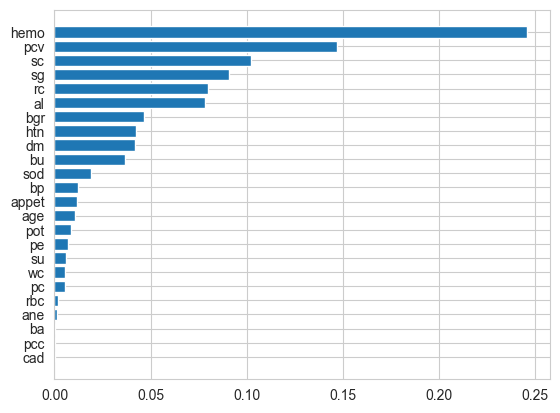

In [19]:
import matplotlib.pyplot as plt
feature_order = feature_importance.sort_values(ascending=False).sort_values()

plt.barh(feature_order.index, feature_order.values)
plt.savefig("feature_importance_embed.png")
plt.show()

In [20]:
embbed_data = df[top_idx.append(pd.Index(['classification']))]

In [21]:
print('Embbed method selected features are',len(top_idx),':',top_idx)

Embbed method selected features are 11 : Index(['hemo', 'pcv', 'sc', 'sg', 'rc', 'al', 'bgr', 'htn', 'dm', 'bu', 'sod'], dtype='object')


# Train model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score,precision_score,f1_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = [
    ('LR', LogisticRegression()),
    ('SVM', SVC(gamma='auto')),
    ('Naive', GaussianNB()),
    ('KNN', KNeighborsClassifier(n_neighbors=2))
]

datasets = {
    'df': df,
    'filter_data': filter_data,
    'wrapper_data': wrapper_data,
    'embbed_data': embbed_data
}

# Open a file in write mode to save the results
with open('classification_reports.txt', 'w') as f:
    length_time = {}
    train_accuracy_fs = {}
    accuracy_fs = {}
    precision_fs = {}
    f1_fs = {}
    recall_fs = {}
    for dataset_name, dataset in datasets.items():
        print(f"Current Dataset: {dataset_name}", file=f)

        X = dataset.drop('classification', axis=1)
        y = dataset['classification']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)


        for model_name, model in models:
            model.fit(X_train, y_train)
            print(f"Model: {model_name}", file=f)

            # Training data
            start = time.time()
            y_train_pred = model.predict(X_train)
            end = time.time()
            duration = end-start
            train_report = classification_report(y_train, y_train_pred)
            train_accuracy = balanced_accuracy_score(y_train,y_train_pred)

            train_accuracy_fs[dataset_name,model_name] = round(train_accuracy*100,2)
            print("Train Classification Report:", file=f)
            print(f"The duration of train data:{round(duration,5)} sec", file=f)
            print(train_report, file=f)
            print(train_report)


            # Test data
            start = time.time()
            y_test_pred = model.predict(X_test)
            end = time.time()
            duration = end-start

            test_report = classification_report(y_test, y_test_pred)
            test_accuracy = balanced_accuracy_score(y_test,y_test_pred)
            test_precision = precision_score(y_test,y_test_pred)
            test_f1 = f1_score(y_test,y_test_pred)
            test_recall = recall_score(y_test,y_test_pred)

            length_time[dataset_name,model_name] = round(duration,5)
            accuracy_fs[dataset_name,model_name] = round(test_accuracy*100,2)
            precision_fs[dataset_name,model_name] = round(test_precision*100,2)
            f1_fs[dataset_name,model_name] = round(test_f1*100,2)
            recall_fs[dataset_name,model_name] = round(test_recall*100,2)


            print("Test Classification Report:", file=f)
            print(f"The duration of test data:{round(duration,5)} sec",file=f)
            print(test_report, file=f)
            print(test_report)
            print(f"The duration of test data:{round(duration,5)} sec")

            print("=" * 40, file=f)

        print("=" * 60, file=f)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       117
           1       0.99      0.99      0.99       163

    accuracy                           0.99       280
   macro avg       0.99      0.99      0.99       280
weighted avg       0.99      0.99      0.99       280

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.99      0.97      0.98        87

    accuracy                           0.97       120
   macro avg       0.95      0.97      0.96       120
weighted avg       0.97      0.97      0.97       120

The duration of test data:0.00099 sec
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       117
           1       1.00      0.97      0.98       163

    accuracy                           0.98       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.98   

# Visualise result

In [23]:
print(length_time)

{('df', 'LR'): 0.00099, ('df', 'SVM'): 0.001, ('df', 'Naive'): 0.0, ('df', 'KNN'): 0.0254, ('filter_data', 'LR'): 0.0, ('filter_data', 'SVM'): 0.00102, ('filter_data', 'Naive'): 0.00101, ('filter_data', 'KNN'): 0.00303, ('wrapper_data', 'LR'): 0.001, ('wrapper_data', 'SVM'): 0.00099, ('wrapper_data', 'Naive'): 0.0, ('wrapper_data', 'KNN'): 0.00308, ('embbed_data', 'LR'): 0.0, ('embbed_data', 'SVM'): 0.001, ('embbed_data', 'Naive'): 0.001, ('embbed_data', 'KNN'): 0.003}


In [24]:
print(recall_fs)

{('df', 'LR'): 96.55, ('df', 'SVM'): 95.4, ('df', 'Naive'): 94.25, ('df', 'KNN'): 88.51, ('filter_data', 'LR'): 95.4, ('filter_data', 'SVM'): 95.4, ('filter_data', 'Naive'): 90.8, ('filter_data', 'KNN'): 95.4, ('wrapper_data', 'LR'): 95.4, ('wrapper_data', 'SVM'): 93.1, ('wrapper_data', 'Naive'): 94.25, ('wrapper_data', 'KNN'): 91.95, ('embbed_data', 'LR'): 96.55, ('embbed_data', 'SVM'): 97.7, ('embbed_data', 'Naive'): 90.8, ('embbed_data', 'KNN'): 96.55}


In [25]:
print(precision_fs)

{('df', 'LR'): 98.82, ('df', 'SVM'): 100.0, ('df', 'Naive'): 100.0, ('df', 'KNN'): 100.0, ('filter_data', 'LR'): 100.0, ('filter_data', 'SVM'): 100.0, ('filter_data', 'Naive'): 100.0, ('filter_data', 'KNN'): 100.0, ('wrapper_data', 'LR'): 100.0, ('wrapper_data', 'SVM'): 100.0, ('wrapper_data', 'Naive'): 100.0, ('wrapper_data', 'KNN'): 100.0, ('embbed_data', 'LR'): 98.82, ('embbed_data', 'SVM'): 98.84, ('embbed_data', 'Naive'): 100.0, ('embbed_data', 'KNN'): 100.0}


In [26]:
print(f1_fs)

{('df', 'LR'): 97.67, ('df', 'SVM'): 97.65, ('df', 'Naive'): 97.04, ('df', 'KNN'): 93.9, ('filter_data', 'LR'): 97.65, ('filter_data', 'SVM'): 97.65, ('filter_data', 'Naive'): 95.18, ('filter_data', 'KNN'): 97.65, ('wrapper_data', 'LR'): 97.65, ('wrapper_data', 'SVM'): 96.43, ('wrapper_data', 'Naive'): 97.04, ('wrapper_data', 'KNN'): 95.81, ('embbed_data', 'LR'): 97.67, ('embbed_data', 'SVM'): 98.27, ('embbed_data', 'Naive'): 95.18, ('embbed_data', 'KNN'): 98.25}


In [27]:
print(accuracy_fs)

{('df', 'LR'): 96.76, ('df', 'SVM'): 97.7, ('df', 'Naive'): 97.13, ('df', 'KNN'): 94.25, ('filter_data', 'LR'): 97.7, ('filter_data', 'SVM'): 97.7, ('filter_data', 'Naive'): 95.4, ('filter_data', 'KNN'): 97.7, ('wrapper_data', 'LR'): 97.7, ('wrapper_data', 'SVM'): 96.55, ('wrapper_data', 'Naive'): 97.13, ('wrapper_data', 'KNN'): 95.98, ('embbed_data', 'LR'): 96.76, ('embbed_data', 'SVM'): 97.34, ('embbed_data', 'Naive'): 95.4, ('embbed_data', 'KNN'): 98.28}


In [28]:
print(train_accuracy_fs)

{('df', 'LR'): 98.53, ('df', 'SVM'): 98.47, ('df', 'Naive'): 96.32, ('df', 'KNN'): 96.32, ('filter_data', 'LR'): 97.92, ('filter_data', 'SVM'): 97.8, ('filter_data', 'Naive'): 94.17, ('filter_data', 'KNN'): 98.47, ('wrapper_data', 'LR'): 98.16, ('wrapper_data', 'SVM'): 96.63, ('wrapper_data', 'Naive'): 96.32, ('wrapper_data', 'KNN'): 98.47, ('embbed_data', 'LR'): 97.92, ('embbed_data', 'SVM'): 98.53, ('embbed_data', 'Naive'): 94.79, ('embbed_data', 'KNN'): 98.77}


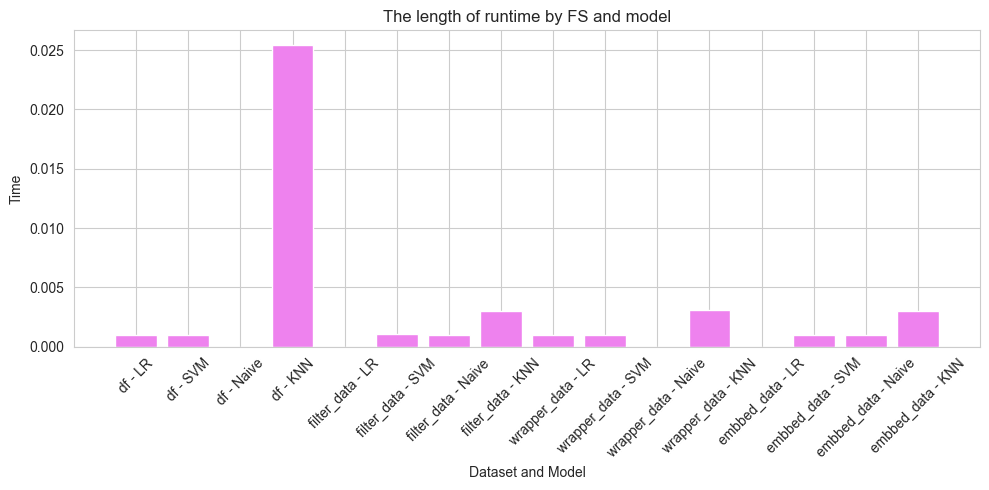

In [29]:
# Extract keys and values from the dictionary
keys = [f"{key[0]} - {key[1]}" for key in length_time.keys()]
values = list(length_time.values())

# Create a bar plot
plt.figure(figsize=(10,5))
plt.bar(keys, values,color = "violet")

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("Time")
plt.title("The length of runtime by FS and model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('LOT by FS and Model')
plt.show()

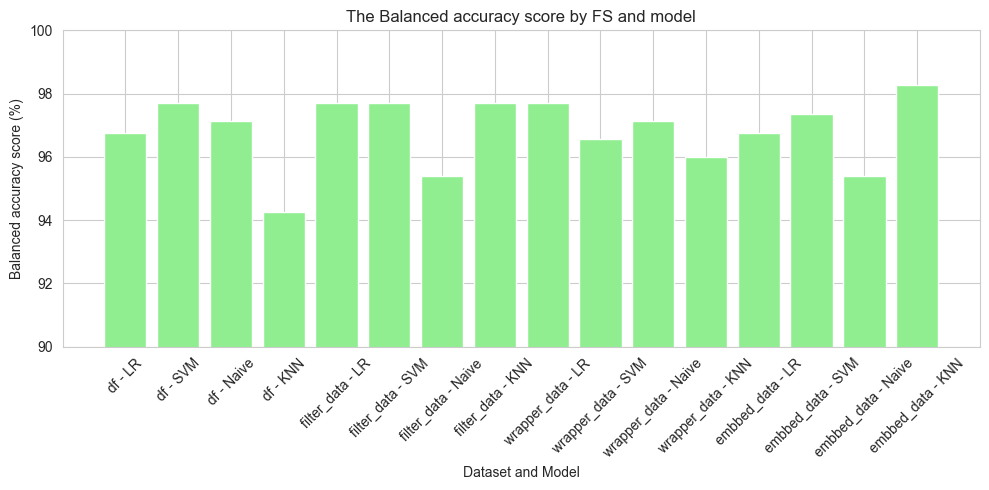

In [30]:
# Extract keys and values from the dictionary
ba_keys = [f"{key[0]} - {key[1]}" for key in accuracy_fs.keys()]
ba_values = list(accuracy_fs.values())

# Create a bar plot
plt.figure(figsize=(10,5))
plt.bar(ba_keys, ba_values,color="lightgreen")

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("Balanced accuracy score (%)")
plt.ylim(90,100)
plt.title("The Balanced accuracy score by FS and model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ba_accuracy by FS and Model')
plt.show()

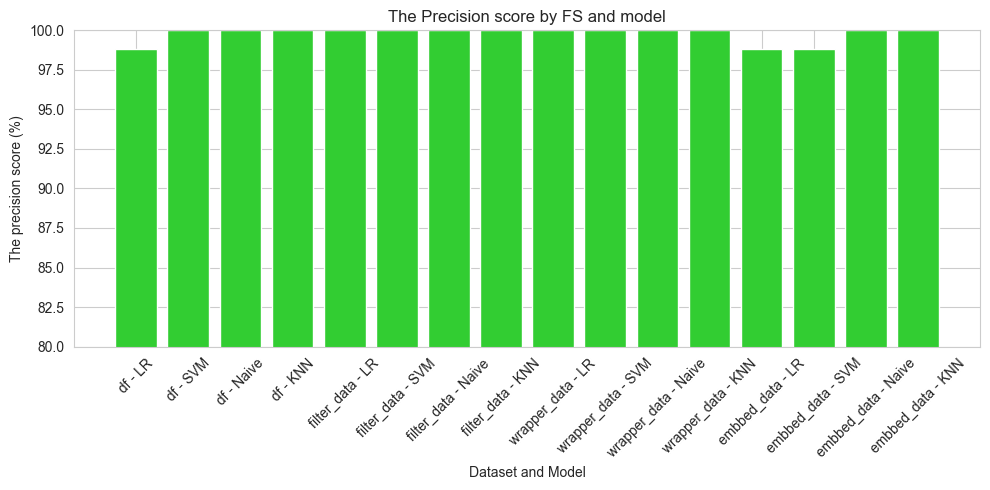

In [31]:
# Extract keys and values from the dictionary
ps_keys = [f"{key[0]} - {key[1]}" for key in precision_fs.keys()]
ps_values = list(precision_fs.values())

# Create a bar plot
plt.figure(figsize=(10,5))
plt.bar(ps_keys, ps_values,color="limegreen")

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The precision score (%)")
plt.ylim(80,100)
plt.title("The Precision score by FS and model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('precision by FS and Model')
plt.show()

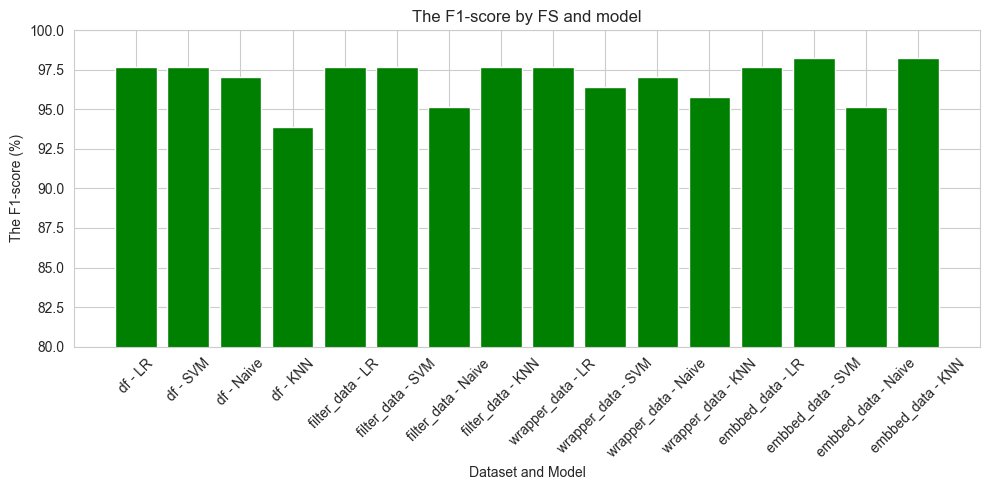

In [32]:
# Extract keys and values from the dictionary
f1_keys = [f"{key[0]} - {key[1]}" for key in f1_fs.keys()]
f1_values = list(f1_fs.values())

# Create a bar plot
plt.figure(figsize=(10,5))
plt.bar(f1_keys, f1_values,color="green")

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The F1-score (%)")
plt.ylim(80,100)
plt.title("The F1-score by FS and model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('f1 by FS and Model')
plt.show()

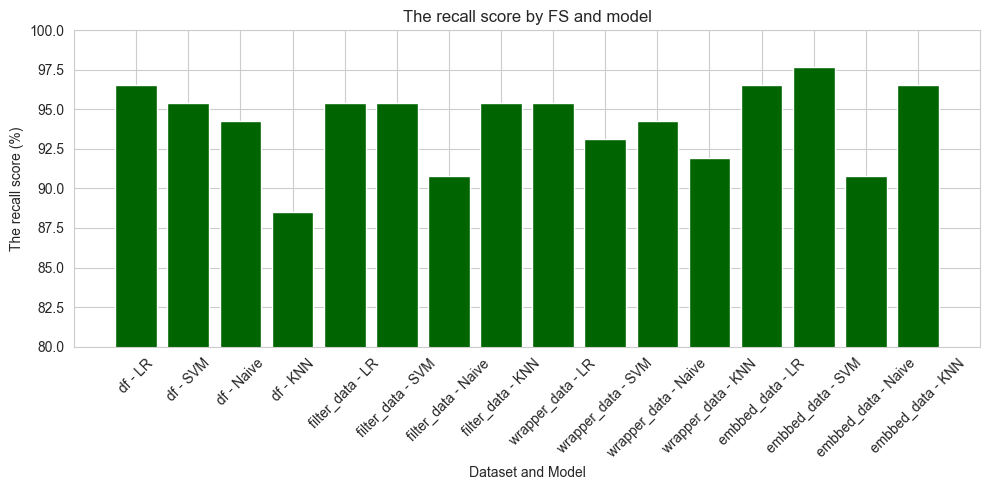

In [33]:
# Extract keys and values from the dictionary
recall_keys = [f"{key[0]} - {key[1]}" for key in recall_fs.keys()]
recall_values = list(recall_fs.values())

# Create a bar plot
plt.figure(figsize=(10,5))
plt.bar(recall_keys, recall_values,color="darkgreen")

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The recall score (%)")
plt.ylim(80,100)
plt.title("The recall score by FS and model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('recall by FS and Model')
plt.show()